# WIFIRE Firemap

Sequential FARSITE simulation using synthetic fire perimeter data.

For each consecutive pair of observed perimeters, FARSITE is run forward from
the earlier perimeter and the prediction is compared against the later observed perimeter.

## Steps
1. Load configuration and perimeter data
2. Configure FARSITE simulation parameters
3. Run sequential FARSITE predictions from first to last observation timesteps 
4. Visualize and compare predictions vs observations
5. Save results

## 1. Setup

In [1]:
import sys
sys.path.insert(0, 'src')

import pandas as pd
import geopandas as gpd
import numpy as np
import json
import matplotlib.pyplot as plt
from pathlib import Path

from farsite import forward_pass_farsite
from geometry import geom_to_state, state_to_geom, plot_geometry
from config import (
    OUTPUT_DIR, DATA_DIR,
    DEFAULT_DIST_RES, DEFAULT_PERIM_RES
)
from firemap import fetch_fire_perimeters, fetch_weather

print('Imports OK')

Imports OK


## 2. Load Configuration and Data

In [2]:
# Load workflow configuration saved by data_preparation.ipynb
with open(DATA_DIR / 'workflow_config.json', 'r') as f:
    workflow_config = json.load(f)

FIRE_NAME        = workflow_config['fire_name']
LCP_PATH         = workflow_config['lcp_path']
IGNITION_DATE    = pd.Timestamp(workflow_config['ignition_date'])
CONTAINMENT_DATE = pd.Timestamp(workflow_config['containment_date'])
PERIMETERS_PATH  = workflow_config['perimeters_path']

print(f'Fire:             {FIRE_NAME}')
print(f'Ignition:         {IGNITION_DATE}')
print(f'Containment:      {CONTAINMENT_DATE}')
print(f'LCP:              {LCP_PATH}')
print(f'Perimeters file:  {PERIMETERS_PATH}')

Fire:             Border 2 Synthetic
Ignition:         2025-01-24 13:00:00
Containment:      2025-01-25 01:00:00
LCP:              landscape.lcp
Perimeters file:  /home/jovyan/work/WIFIRE-Firemap-for-NDP/outputs/border_2_synthetic_perimeters.geojson


In [3]:
# Load perimeters — sorted oldest → newest by data_preparation.ipynb
perimeters_gdf = gpd.read_file(PERIMETERS_PATH)
perimeters_gdf['datetime'] = pd.to_datetime(perimeters_gdf['datetime'])

print(f'Loaded {len(perimeters_gdf)} perimeters')
for i, row in perimeters_gdf.iterrows():
    print(f'  [{i}] {row["datetime"]}  —  {row.geometry.area / 1e6:.2f} km²')

Loaded 13 perimeters
  [0] 2025-01-24 13:00:00  —  0.04 km²
  [1] 2025-01-24 14:00:00  —  0.38 km²
  [2] 2025-01-24 15:00:00  —  0.94 km²
  [3] 2025-01-24 16:00:00  —  2.03 km²
  [4] 2025-01-24 17:00:00  —  3.49 km²
  [5] 2025-01-24 18:00:00  —  5.74 km²
  [6] 2025-01-24 19:00:00  —  9.00 km²
  [7] 2025-01-24 20:00:00  —  13.72 km²
  [8] 2025-01-24 21:00:00  —  21.99 km²
  [9] 2025-01-24 22:00:00  —  31.39 km²
  [10] 2025-01-24 23:00:00  —  39.84 km²
  [11] 2025-01-25 00:00:00  —  49.62 km²
  [12] 2025-01-25 01:00:00  —  55.94 km²


In [4]:
# Weather query location
wx_lat = workflow_config['weather_location']['lat']
wx_lon = workflow_config['weather_location']['lon']
print(f'Weather query location: ({wx_lat:.4f}, {wx_lon:.4f})')

Weather query location: (32.5959, -116.8571)


## 3. Configure FARSITE Parameters

In [5]:
DIST_RES  = DEFAULT_DIST_RES   # meters
PERIM_RES = DEFAULT_PERIM_RES  # meters

print('FARSITE Parameters:')
print(f'  Distance resolution:  {DIST_RES} m')
print(f'  Perimeter resolution: {PERIM_RES} m')
print(f'  LCP path:             {LCP_PATH}')

FARSITE Parameters:
  Distance resolution:  150 m
  Perimeter resolution: 150 m
  LCP path:             landscape.lcp


## 4. Sequential FARSITE Simulation

For each consecutive pair of perimeters (t → t+1):
1. Fetch observed weather for the interval
2. Run FARSITE forward from perimeter at time t
3. Store predicted perimeter and compare to observation at t+1

In [6]:
n_timesteps = len(perimeters_gdf) - 1

results = {
    'timestep':       [],
    'start_datetime': [],
    'end_datetime':   [],
    'initial_geom':   [],
    'observed_geom':  [],
    'predicted_geom': [],
    'wind_speed':     [],
    'wind_direction': [],
    'farsite_success': [],
}

print(f'Running {n_timesteps} timestep(s)...')
print('=' * 70)

for t in range(n_timesteps):
    print(f'\nTimestep {t} → {t+1}')
    print('-' * 40)

    current_obs = perimeters_gdf.iloc[t]
    next_obs    = perimeters_gdf.iloc[t + 1]

    current_time = pd.Timestamp(current_obs['datetime'])
    next_time    = pd.Timestamp(next_obs['datetime'])
    dt           = next_time - current_time

    print(f'  Period: {current_time}  →  {next_time}  ({dt})')

    initial_poly  = current_obs.geometry
    observed_poly = next_obs.geometry

    # ── Fetch weather for this interval ──────────────────────────────────
    try:
        weather = fetch_weather(
            lat=wx_lat,
            lon=wx_lon,
            start_dt=current_time,
            end_dt=next_time,
            verbose=False
        )
        wind_speed     = weather['windspeed']
        wind_direction = weather['winddirection']
    except Exception as e:
        print(f'  ⚠  Weather fetch failed ({e}), using defaults: 5 mph @ 270°')
        wind_speed, wind_direction = 5.0, 270.0

    print(f'  Wind: {wind_speed:.1f} mph @ {wind_direction:.0f}°')

    # ── Run FARSITE ───────────────────────────────────────────────────────
    farsite_params = {
        'windspeed':     int(wind_speed),
        'winddirection': int(wind_direction),
        'dt':            dt,
    }

    start_time_str = current_time.strftime('%Y-%m-%d %H:%M:%S')

    predicted_poly = forward_pass_farsite(
        poly=initial_poly,
        params=farsite_params,
        start_time=start_time_str,
        lcppath=LCP_PATH,
        dist_res=DIST_RES,
        perim_res=PERIM_RES,
    )

    success = predicted_poly is not None
    if success:
        pred_area = predicted_poly.area / 1e6
        obs_area  = observed_poly.area / 1e6
        print(f'  ✓ FARSITE succeeded')
        print(f'    Predicted area:  {pred_area:.2f} km²')
        print(f'    Observed area:   {obs_area:.2f} km²')
        print(f'    Area error:      {abs(pred_area - obs_area):.2f} km²')
    else:
        print(f'  ✗ FARSITE failed — storing None for this timestep')

    # ── Store results ─────────────────────────────────────────────────────
    results['timestep'].append(t)
    results['start_datetime'].append(current_time)
    results['end_datetime'].append(next_time)
    results['initial_geom'].append(initial_poly)
    results['observed_geom'].append(observed_poly)
    results['predicted_geom'].append(predicted_poly)
    results['wind_speed'].append(wind_speed)
    results['wind_direction'].append(wind_direction)
    results['farsite_success'].append(success)

print('\n' + '=' * 70)
successful = sum(results['farsite_success'])
print(f'\nCompleted: {successful}/{n_timesteps} timesteps succeeded')

Running 12 timestep(s)...

Timestep 0 → 1
----------------------------------------
  Period: 2025-01-24 13:00:00  →  2025-01-24 14:00:00  (0 days 01:00:00)
  Wind: 5.0 mph @ 270°
  ✓ FARSITE succeeded
    Predicted area:  0.22 km²
    Observed area:   0.38 km²
    Area error:      0.15 km²

Timestep 1 → 2
----------------------------------------
  Period: 2025-01-24 14:00:00  →  2025-01-24 15:00:00  (0 days 01:00:00)
  Wind: 5.0 mph @ 270°
  ✓ FARSITE succeeded
    Predicted area:  0.62 km²
    Observed area:   0.94 km²
    Area error:      0.33 km²

Timestep 2 → 3
----------------------------------------
  Period: 2025-01-24 15:00:00  →  2025-01-24 16:00:00  (0 days 01:00:00)
  Wind: 5.0 mph @ 270°
  ✓ FARSITE succeeded
    Predicted area:  1.56 km²
    Observed area:   2.03 km²
    Area error:      0.48 km²

Timestep 3 → 4
----------------------------------------
  Period: 2025-01-24 16:00:00  →  2025-01-24 17:00:00  (0 days 01:00:00)
  Wind: 5.0 mph @ 270°
  ✓ FARSITE succeeded
    

## 5. Visualize Results

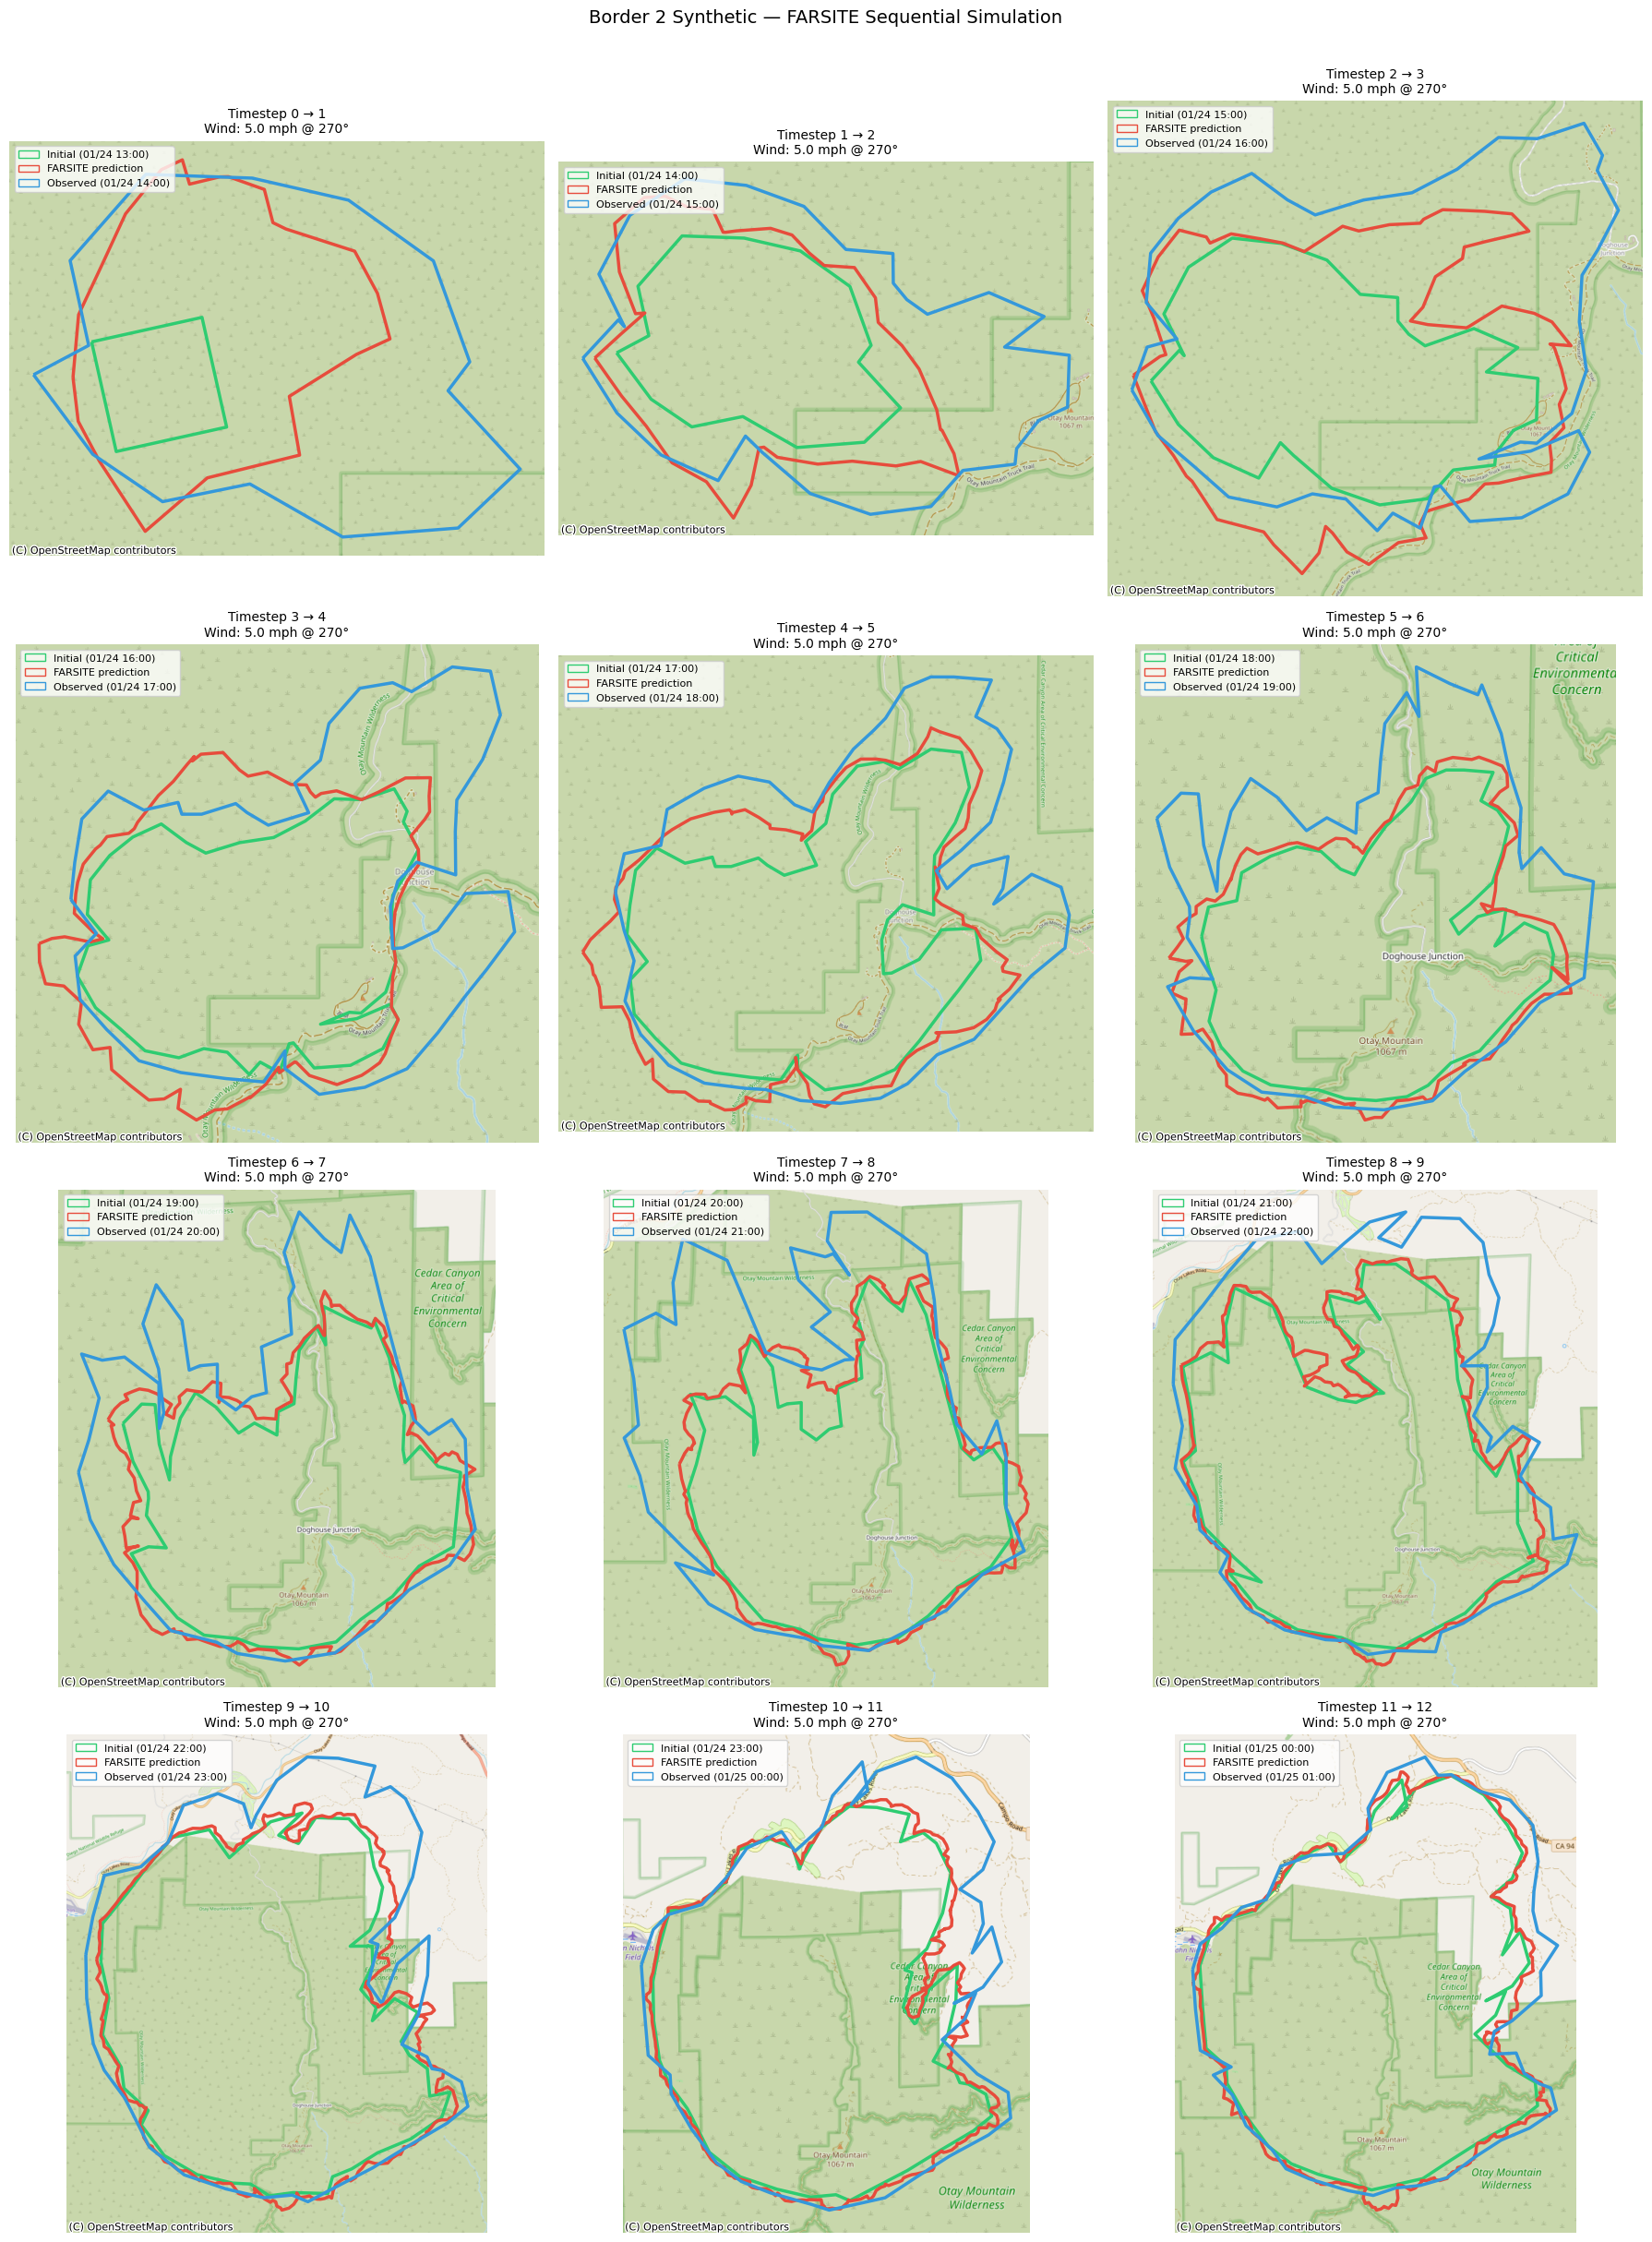

Figure saved.


In [7]:
import contextily as ctx
from matplotlib.patches import Patch

n_valid = sum(results['farsite_success'])
n_cols  = min(3, n_valid)
n_rows  = max(1, (n_valid + n_cols - 1) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 6 * n_rows))
axes = np.array(axes).flatten() if n_valid > 1 else [axes]

ax_idx = 0
for t, success in enumerate(results['farsite_success']):
    if not success:
        continue

    ax = axes[ax_idx]
    ax_idx += 1

    initial_poly   = results['initial_geom'][t]
    observed_poly  = results['observed_geom'][t]
    predicted_poly = results['predicted_geom'][t]
    t0             = results['start_datetime'][t]
    t1             = results['end_datetime'][t]

    # Plot each perimeter
    for poly, color, label in [
        (initial_poly,   '#2ecc71', f'Initial ({t0.strftime("%m/%d %H:%M")})'),
        (predicted_poly, '#e74c3c', f'FARSITE prediction'),
        (observed_poly,  '#3498db', f'Observed ({t1.strftime("%m/%d %H:%M")})'),
    ]:
        gpd.GeoSeries([poly], crs='EPSG:5070').to_crs('EPSG:3857').boundary.plot(
            ax=ax, color=color, linewidth=2.5
        )

    # Add basemap
    try:
        ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, crs='EPSG:3857')
    except Exception:
        pass

    legend_elements = [
        Patch(facecolor='none', edgecolor='#2ecc71', label=f'Initial ({t0.strftime("%m/%d %H:%M")})'),
        Patch(facecolor='none', edgecolor='#e74c3c', label='FARSITE prediction'),
        Patch(facecolor='none', edgecolor='#3498db', label=f'Observed ({t1.strftime("%m/%d %H:%M")})'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=8)
    ax.set_title(f'Timestep {t} → {t+1}\n'
                 f'Wind: {results["wind_speed"][t]:.1f} mph @ {results["wind_direction"][t]:.0f}°',
                 fontsize=10)
    ax.set_axis_off()

# Hide unused axes
for i in range(ax_idx, len(axes)):
    axes[i].set_visible(False)

fig.suptitle(f'{FIRE_NAME} — FARSITE Sequential Simulation', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{FIRE_NAME.lower().replace(' ', '_')}_farsite_results.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved.')

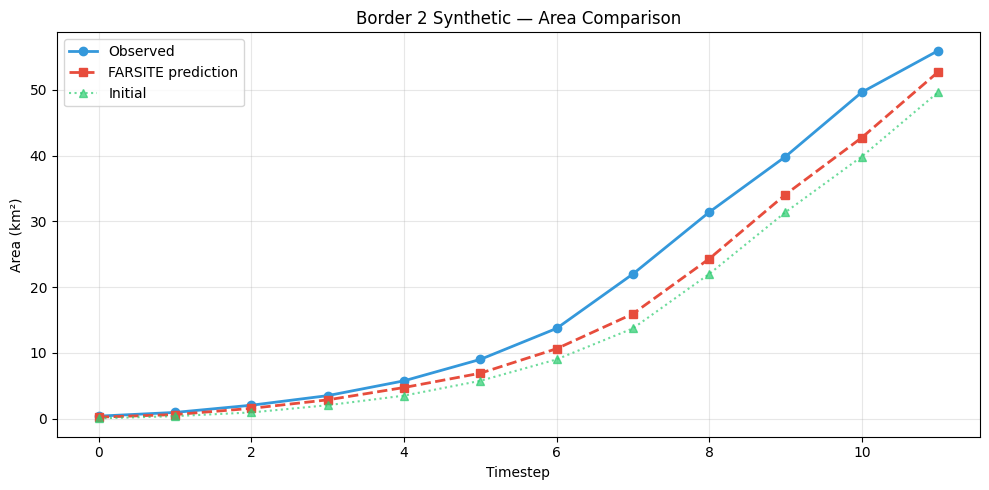

In [8]:
# Area comparison plot
fig, ax = plt.subplots(figsize=(10, 5))

timesteps = results['timestep']
obs_areas  = [g.area / 1e6 for g in results['observed_geom']]
pred_areas = [g.area / 1e6 if g is not None else None for g in results['predicted_geom']]
init_areas = [g.area / 1e6 for g in results['initial_geom']]

ax.plot(timesteps, obs_areas,  'o-', color='#3498db', label='Observed', linewidth=2)
ax.plot(timesteps, pred_areas, 's--', color='#e74c3c', label='FARSITE prediction', linewidth=2)
ax.plot(timesteps, init_areas, '^:', color='#2ecc71', label='Initial', linewidth=1.5, alpha=0.7)

ax.set_xlabel('Timestep')
ax.set_ylabel('Area (km²)')
ax.set_title(f'{FIRE_NAME} — Area Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{FIRE_NAME.lower().replace(' ', '_')}_area_comparison.png",
            dpi=150, bbox_inches='tight')
plt.show()

## 6. Accuracy Metrics

In [9]:
from shapely.validation import make_valid

def safe_iou(obs, pred):
    """Compute IoU between two geometries, making them valid first."""
    obs  = make_valid(obs)
    pred = make_valid(pred)
    try:
        intersection = obs.intersection(pred).area
        union        = obs.union(pred).area
        return intersection / union if union > 0 else 0.0
    except Exception:
        # Fall back to buffer(0) trick if make_valid wasn't enough
        obs  = obs.buffer(0)
        pred = pred.buffer(0)
        intersection = obs.intersection(pred).area
        union        = obs.union(pred).area
        return intersection / union if union > 0 else 0.0

print('Prediction accuracy per timestep:')
print('-' * 65)
print(f'{"Timestep":<10} {"Observed km²":<15} {"Predicted km²":<16} {"IoU":<8} {"Area Error %"}')
print('-' * 65)

for t in range(n_timesteps):
    obs  = results['observed_geom'][t]
    pred = results['predicted_geom'][t]

    if pred is None:
        print(f'{t:<10} {obs.area/1e6:<15.2f} {"FAILED":<16} {"-":<8} -')
        continue

    iou          = safe_iou(obs, pred)
    area_err_pct = abs(pred.area - obs.area) / obs.area * 100

    print(f'{t:<10} {obs.area/1e6:<15.2f} {pred.area/1e6:<16.2f} {iou:<8.3f} {area_err_pct:.1f}%')

print('-' * 65)

Prediction accuracy per timestep:
-----------------------------------------------------------------
Timestep   Observed km²    Predicted km²    IoU      Area Error %
-----------------------------------------------------------------
0          0.38            0.22             0.559    41.2%
1          0.94            0.62             0.616    34.6%
2          2.03            1.56             0.646    23.4%
3          3.49            2.85             0.619    18.4%
4          5.74            4.73             0.739    17.7%
5          9.00            6.90             0.730    23.3%
6          13.72           10.63            0.754    22.5%
7          21.99           15.93            0.690    27.5%
8          31.39           24.30            0.767    22.6%
9          39.84           34.08            0.831    14.5%
10         49.62           42.72            0.848    13.9%
11         55.94           52.70            0.914    5.8%
-------------------------------------------------------------

## 7. Save Results

In [10]:
# Save as GeoDataFrame (predicted perimeters)
valid_indices = [t for t in range(n_timesteps) if results['farsite_success'][t]]

results_gdf = gpd.GeoDataFrame(
    {
        'timestep':       [results['timestep'][t]        for t in valid_indices],
        'start_datetime': [results['start_datetime'][t]  for t in valid_indices],
        'end_datetime':   [results['end_datetime'][t]    for t in valid_indices],
        'wind_speed_mph': [results['wind_speed'][t]      for t in valid_indices],
        'wind_dir_deg':   [results['wind_direction'][t]  for t in valid_indices],
        'area_km2':       [results['predicted_geom'][t].area / 1e6 for t in valid_indices],
        'geometry':       [results['predicted_geom'][t]  for t in valid_indices],
    },
    crs='EPSG:5070'
)

fire_slug = FIRE_NAME.lower().replace(' ', '_')
out_path  = OUTPUT_DIR / f'{fire_slug}_farsite_predictions.geojson'
results_gdf.to_crs('EPSG:4326').to_file(out_path, driver='GeoJSON')
print(f'Saved {len(results_gdf)} predicted perimeters → {out_path}')

# Also pickle the full results dict
import pickle
pkl_path = OUTPUT_DIR / f'{fire_slug}_farsite_results.pkl'
with open(pkl_path, 'wb') as f:
    pickle.dump(results, f)
print(f'Full results dict saved → {pkl_path}')

Saved 12 predicted perimeters → /home/jovyan/work/WIFIRE-Firemap-for-NDP/outputs/border_2_synthetic_farsite_predictions.geojson
Full results dict saved → /home/jovyan/work/WIFIRE-Firemap-for-NDP/outputs/border_2_synthetic_farsite_results.pkl


In [11]:
# Summary
print('\n' + '=' * 60)
print('SIMULATION SUMMARY')
print('=' * 60)
print(f'Fire:                  {FIRE_NAME}')
print(f'Timesteps attempted:   {n_timesteps}')
print(f'Timesteps succeeded:   {sum(results["farsite_success"])}')
if results['initial_geom']:
    print(f'Initial area:          {results["initial_geom"][0].area / 1e6:.2f} km²')
    print(f'Final observed area:   {results["observed_geom"][-1].area / 1e6:.2f} km²')
    last_pred = results['predicted_geom'][-1]
    if last_pred is not None:
        print(f'Final predicted area:  {last_pred.area / 1e6:.2f} km²')


SIMULATION SUMMARY
Fire:                  Border 2 Synthetic
Timesteps attempted:   12
Timesteps succeeded:   12
Initial area:          0.04 km²
Final observed area:   55.94 km²
Final predicted area:  52.70 km²
